# Model Evaluation 

Up until now we have focused model evaluation on accuracy. While accuracy is useful in for classification tasks, it does not always provide a complete picture of a model's performance.

In this notebook we will explore additional metrics suitable for binary classification problems, namely:

- **Receiver Operating Characteristic (ROC) curve**: A graphical representation of the diagnostic ability of a binary classifier across a range of thresholds.

- **Detection Error Tradeoff (DET) curve**: A graphical representation for assessing the trade-offs between different types of classification errors

These metrics provide a deeper insight into the performance characteristics of a binary classifier.

Note that these metrics can be extended to multi-classification problems.

In [87]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

## Auxiliary functions from previous classes

In [88]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    max_k = 15

    preds = []
    ground_truth = []
    imgs = torch.Tensor(max_k, 3, IMAGE_SIZE, IMAGE_SIZE)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE
    while k < max_k and iters < max_iters:

        images, targets = next(iterator)
        #print(images[0].shape)
        logits = model(images.to(device))
        
        #print(predictions[0])
        predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < max_k:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 5, 3)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        v_correct = 0
        val_loss = 0.0
        with torch.no_grad():
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss.cpu().detach().numpy())
        history['loss'].append(epoch_loss.cpu().detach().numpy())
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 128, 5)
        self.bn1 = torch.nn.BatchNorm2d(128)
        self.relu1 = torch.nn.LeakyReLU()

        self.conv2 = torch.nn.Conv2d(128, 128, 5)
        self.bn2 = torch.nn.BatchNorm2d(128)
        self.relu2 = torch.nn.LeakyReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(128, 256, 5)
        self.bn3 = torch.nn.BatchNorm2d(256)
        self.relu3 = torch.nn.LeakyReLU()

        self.conv4 = torch.nn.Conv2d(256, 256, 5, padding = 'same')
        self.bn4 = torch.nn.BatchNorm2d(256)
        self.relu4 = torch.nn.LeakyReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.conv5 = torch.nn.Conv2d(256, 512, 5)
        self.bn5 = torch.nn.BatchNorm2d(512)
        self.relu5 = torch.nn.LeakyReLU()

        self.conv6 = torch.nn.Conv2d(512, 512, 3, padding = 'same')
        self.bn6 = torch.nn.BatchNorm2d(512)
        self.relu6 = torch.nn.LeakyReLU()

        self.maxpool3 = torch.nn.MaxPool2d(2)

        self.conv7 = torch.nn.Conv2d(512, 512, 3, padding = 'same')
        self.bn7 = torch.nn.BatchNorm2d(512)
        self.relu7 = torch.nn.LeakyReLU()

        self.maxpool4 = torch.nn.MaxPool2d(2)

        self.conv8 = torch.nn.Conv2d(512, 512, 3, padding = 'same')
        self.bn8 = torch.nn.BatchNorm2d(512)
        self.relu8 = torch.nn.LeakyReLU()

        self.maxpool5 = torch.nn.MaxPool2d(2)
        
        self.fc1 = torch.nn.Linear(25088, 128)
        self.relu9 = torch.nn.LeakyReLU()
        self.do = torch.nn.Dropout(0.5)
        self.fc2 = torch.nn.Linear(128, 2)

        

    def forward(self, x):    
        
        # input = (bs, 3, 256, 256)
        x = self.conv1(x) # -> (bs, 128, 252, 252)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 128, 248, 248)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x) # -> (bs, 128, 124, 124)
        
        x = self.conv3(x) # -> (bs, 256, 120, 120)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 256, 116, 116)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x) # -> (bs, 256, 58, 58)

        x = self.conv5(x) # -> (bs, 512, 56, 56)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.conv6(x) # -> (bs, 512, 56, 56)
        x = self.bn6(x)
        x = self.relu6(x)
        x = self.maxpool3(x) # -> (bs, 512, 28, 28)        

        x = self.conv7(x) # -> (bs, 512, 28, 28)
        x = self.bn7(x)
        x = self.relu7(x)
        x = self.maxpool4(x) # -> (bs, 512, 14, 14)  

        x = self.conv8(x) # -> (bs, 512, 14, 14)
        x = self.bn8(x)
        x = self.relu8(x)
        x = self.maxpool5(x) # -> (bs, 512, 7, 7)  

        x = torch.flatten(x,1) # -> (bs, 512 x 7 x 7 = 25088)
        x = self.fc1(x)        # -> (bs, 10)
        x = self.relu9(x)
        x = self.do(x)
        x = self.fc2(x)

        return(x)



class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    


def build_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_confusion_matrix(ground_truth, preds, len(test_set.classes))      


## Settings

In [89]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'd:/vcpi/chestXRay'

PATH_TRAINING_SET = f'{BASE_PATH}/train'
PATH_TEST_SET = f'{BASE_PATH}/test'

BATCH_SIZE = 8

IMAGE_SIZE = 256

EPOCHS = 10

RUNS = 5

cuda:0


## The dataset

In this notebook we will use the Chest X-Ray [dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

This dataset is comprised of x-ray images categorized into two classes: normal and pneumonia

In [90]:
transform = v2.Compose(
    [v2.Resize((IMAGE_SIZE, IMAGE_SIZE)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_sub, val_sub = torch.utils.data.random_split(train_set, [0.8, 0.2])

train_loader = torch.utils.data.DataLoader(train_sub, batch_size = BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_sub, batch_size = BATCH_SIZE)

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

Batch shape:  torch.Size([8, 3, 256, 256])


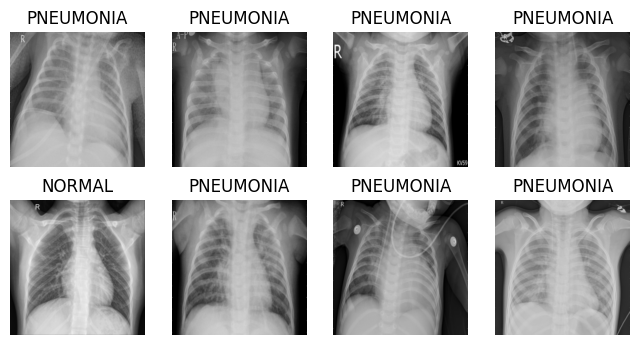

<Figure size 640x480 with 0 Axes>

In [91]:
images, targets = next(iter(train_loader))
print("Batch shape: ", images.shape)
vcpi_util.show_images(2,4, images, targets, train_set.classes) 

## Training

In [92]:
loss_fn = torch.nn.CrossEntropyLoss()

model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

early_stop = Early_Stopping(9)
optimizer = torch.optim.Adam(model_Conv.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    


In [93]:
torchinfo.summary(model_Conv, input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
Conv                                     [8, 2]                    --
├─Conv2d: 1-1                            [8, 128, 252, 252]        9,728
├─BatchNorm2d: 1-2                       [8, 128, 252, 252]        256
├─LeakyReLU: 1-3                         [8, 128, 252, 252]        --
├─Conv2d: 1-4                            [8, 128, 248, 248]        409,728
├─BatchNorm2d: 1-5                       [8, 128, 248, 248]        256
├─LeakyReLU: 1-6                         [8, 128, 248, 248]        --
├─MaxPool2d: 1-7                         [8, 128, 124, 124]        --
├─Conv2d: 1-8                            [8, 256, 120, 120]        819,456
├─BatchNorm2d: 1-9                       [8, 256, 120, 120]        512
├─LeakyReLU: 1-10                        [8, 256, 120, 120]        --
├─Conv2d: 1-11                           [8, 256, 120, 120]        1,638,656
├─BatchNorm2d: 1-12                      [8, 256, 120, 120]   

In [34]:
history = train_III(model_Conv, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'xray')

Epoch: 000; Loss: 0.071676; Accuracy: 79.4342; Val Loss: 0.038701; Val Acc: 87.4761; Elapsed time: 166.1200
Epoch: 001; Loss: 0.039061; Accuracy: 88.1498; Val Loss: 0.039914; Val Acc: 87.9541; Elapsed time: 113.4977
Epoch: 002; Loss: 0.034852; Accuracy: 91.3417; Val Loss: 0.096931; Val Acc: 83.4608; Elapsed time: 112.0094
Epoch: 003; Loss: 0.029057; Accuracy: 92.9855; Val Loss: 0.024758; Val Acc: 92.5430; Elapsed time: 120.7240
Epoch: 004; Loss: 0.026546; Accuracy: 93.5398; Val Loss: 0.031874; Val Acc: 88.7189; Elapsed time: 119.7719
Epoch: 005; Loss: 0.022368; Accuracy: 93.9603; Val Loss: 0.017469; Val Acc: 94.7419; Elapsed time: 116.6300
Epoch: 006; Loss: 0.017545; Accuracy: 95.0115; Val Loss: 0.016985; Val Acc: 94.6463; Elapsed time: 121.6722
Epoch: 007; Loss: 0.020254; Accuracy: 94.9159; Val Loss: 0.013773; Val Acc: 96.1759; Elapsed time: 107.2357
Epoch: 008; Loss: 0.018944; Accuracy: 95.0688; Val Loss: 0.025307; Val Acc: 95.2199; Elapsed time: 107.4838
Epoch: 009; Loss: 0.015409; 

## Evaluating

In [94]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

reload = torch.load(f'xray_best.pt')
model_Conv.load_state_dict(reload['model'])
eval = evaluate(model_Conv, test_loader)
eval_val = evaluate(model_Conv, val_loader)
print(reload['epoch'], eval, eval_val)


9 0.8092948794364929 0.9435946345329285


Show misclassifications

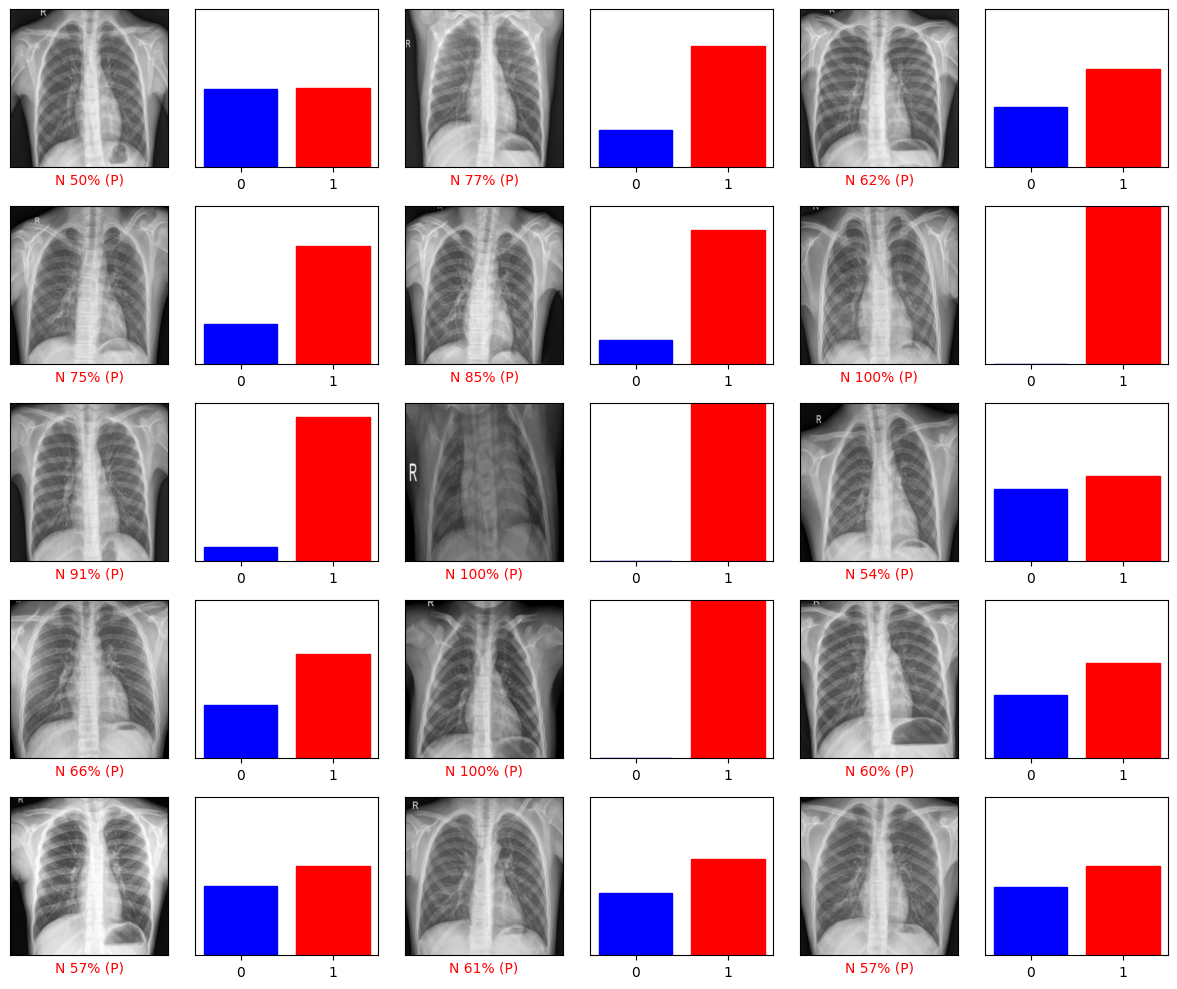

In [95]:
show_bad_preds(model_Conv, test_loader, ['P', 'N'])   

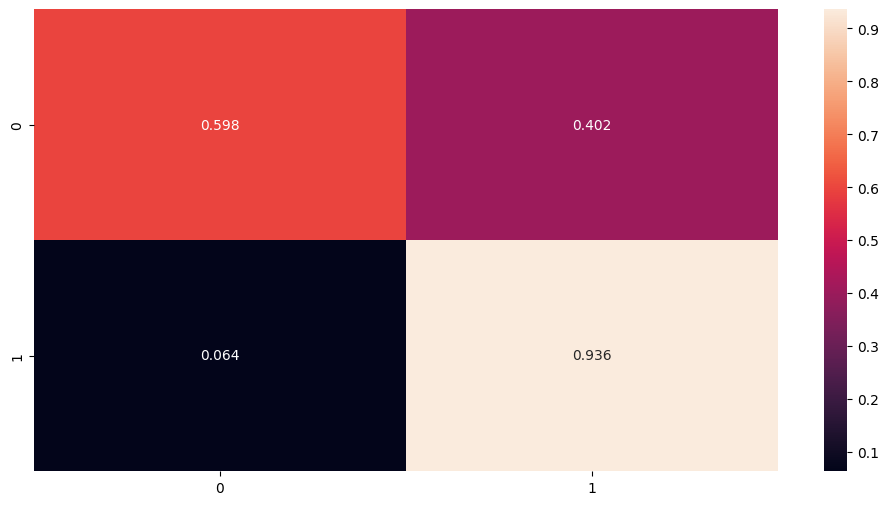

In [96]:
build_confusion_matrix(model_Conv, test_loader)

Confusion Matrix Interpretation

|                  | Predicted Normal | Predicted Pneumonia |
|------------------|------------------|---------------------|
| Actual Normal    | True Negatives   | False Positives     |
| Actual Pneumonia | False Negatives  | True Positives      |


Confusion matrix with labels


|                  | Predicted Normal | Predicted Pneumonia |
|------------------|------------------|---------------------|
| Actual Normal    | 140              | 94                  |
| Actual Pneumonia |  25              | 365               |


# ROC Curve and AUC

The ROC curve depicts graphically the performance of a model at different classification thresholds. The graph plots two parameters:

True Positive Rate $TPR = \Large \frac{TP }{TP + FN}$

False Positive Rate $FPR = \Large \frac{FP }{FP + TN}$

In the above Confusion Matrix we have

$TPR = {\Large \frac{365 }{365 + 25}} = 0.936$

$FPR = {\Large \frac{94 }{94 + 140}} = 0.402$

The above values were computed considering a threshold of 0.5. That is, if the model's output for the pneumonia class is above 0.5 then the sample is classified as belonging to the pneumonia class .

In [97]:
preds = []
ground_truth = []
model_Conv.eval()

for images, targets in test_loader:
    
    logits = model_Conv(images.to(device))
    p = torch.nn.functional.softmax(logits, dim=1).detach().cpu().numpy()
    preds.extend(p)
    ground_truth.extend(targets.numpy())


In [98]:
p = [x[1] for x in preds]

normal = [p[i] for i in range(len(p)) if ground_truth[i] == 0]
pneu = [p[i] for i in range(len(p)) if ground_truth[i] == 1]


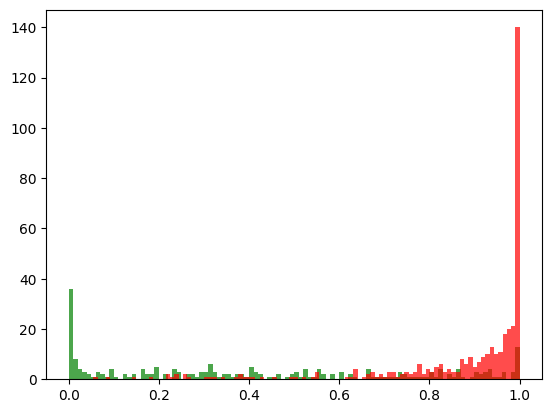

In [99]:
plt.hist(normal, 100, density = 0, color ='green', alpha = 0.7)
plt.hist(pneu, 100, density = 0, color ='red', alpha = 0.7)
plt.show()

It is possible to achieve higher accuracy levels if the threshold is set at the right value. However, this only works if the dataset we use to fine tune the threshold is truly representative of the underlying distribution of the problem.

In [100]:
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

bin = [0 if x < 0.63 else 1  for x in p]

accuracy_score(ground_truth, bin)

0.8333333333333334

### ROC curve for the pneumonia class

In [110]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(ground_truth, p)

In [115]:
print(fpr[:3], tpr[:3], thresholds[:3])
print(fpr[-3:], tpr[-3:], thresholds[-3:])

[0.         0.0042735  0.01282051] [0.         0.05897436 0.06153846] [      inf 1.        0.9999999]
[0.77350427 0.77350427 1.        ] [0.9974359 1.        1.       ] [5.7735853e-02 5.4766443e-02 3.1360555e-14]


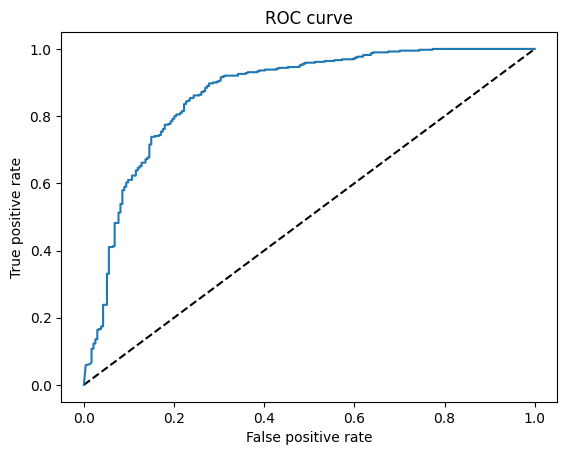

In [103]:
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

plt.show()

In [104]:
from sklearn.metrics import auc
auc_model = auc(fpr, tpr)

print(auc_model)

0.8687869822485207


# Det Curve

In a Detection Error Tradeoff (DET) curve, the False Positive Rate (FPR) and False Negative Rate (FNR) are plotted to illustrate the trade-off between the two types of classification errors.

False Positive Rate: $FPR = \Large \frac{FP }{FP + TN}$

False Negative Rate, aka miss rate: $FPR = \Large \frac{FN }{FN + TP}$

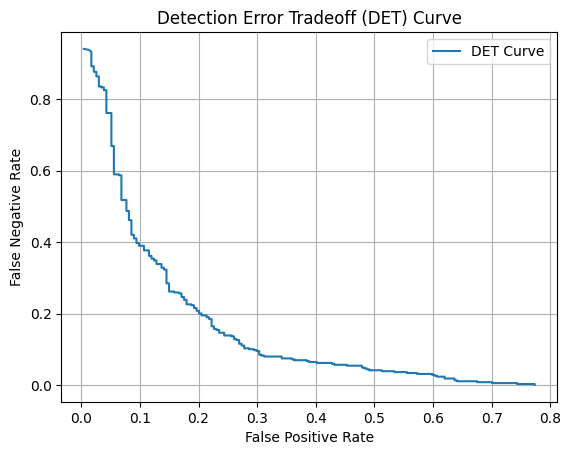

In [105]:
from sklearn.metrics import det_curve

fpr, fnr, _ = det_curve(ground_truth, p)

plt.plot(fpr, fnr, label='DET Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('False Negative Rate')
plt.title('Detection Error Tradeoff (DET) Curve')
plt.grid()
plt.legend()
plt.show()

In [116]:
mini = np.min([p[i] for i in range(len(p)) if ground_truth[i] == 1])
print(min)

0.054766443
